In [33]:
!pip install e2b-code-interpreter gradio_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.8/321.8 kB 10.6 MB/s eta 0:00:00


In [47]:
from e2b_code_interpreter import Sandbox
from google.colab import userdata

sbx = Sandbox(
    api_key = userdata.get("E2B_API_KEY"),
    template ="desktop"
) # By default the sandbox is alive for 5 minutes

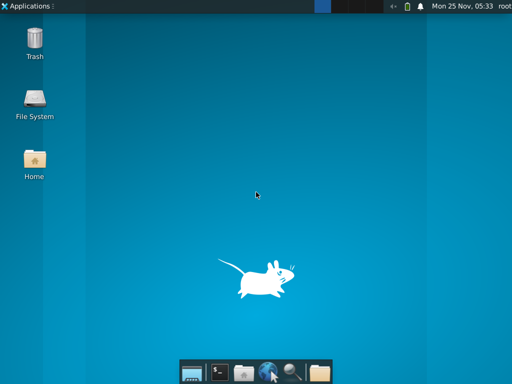

In [48]:
# https://blog.jamesmurdza.com/how-i-taught-an-ai-to-use-a-computer
# https://github.com/jordansissel/xdotool
screenshot_path= "screenshot.png"
sbx.commands.run(f"scrot --pointer {screenshot_path}")
screenshot = sbx.files.read(screenshot_path, format="bytes")
sbx.files.remove(screenshot_path)

from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display

img = PILImage.open(BytesIO(screenshot))

width, height = img.size
new_width = int(width * 0.5)
new_height = int(height * 0.5)
small_img = img.resize((new_width, new_height))

img.save("screenshot.png")

display(small_img)

In [49]:
sbx.commands.run("xdotool mousemove 550 750")

CommandResult(stderr='', stdout='', exit_code=0, error='')

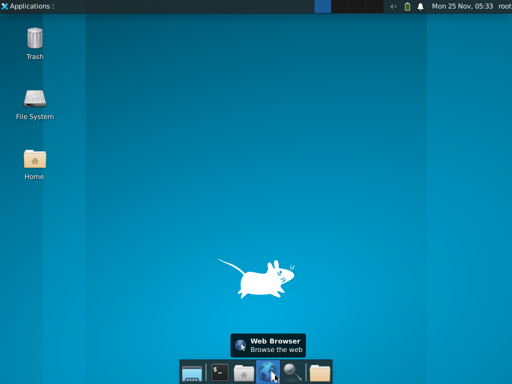

In [50]:
screenshot_path= "screenshot.png"
sbx.commands.run(f"scrot --pointer {screenshot_path}")
screenshot = sbx.files.read(screenshot_path, format="bytes")
sbx.files.remove(screenshot_path)

from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display

img = PILImage.open(BytesIO(screenshot))

width, height = img.size
new_width = int(width * 0.5)
new_height = int(height * 0.5)
small_img = img.resize((new_width, new_height))

img.save("screenshot.png")


display(small_img)

In [51]:
sbx.commands.run("xdotool click 1")

CommandResult(stderr='', stdout='', exit_code=0, error='')

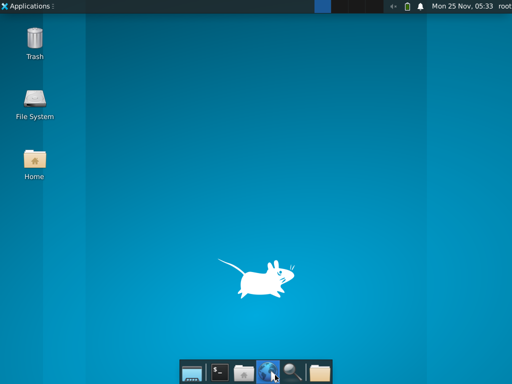

In [52]:
screenshot_path= "screenshot.png"
sbx.commands.run(f"scrot --pointer {screenshot_path}")
screenshot = sbx.files.read(screenshot_path, format="bytes")
sbx.files.remove(screenshot_path)

from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display

img = PILImage.open(BytesIO(screenshot))

width, height = img.size
new_width = int(width * 0.5)
new_height = int(height * 0.5)
small_img = img.resize((new_width, new_height))

img.save("screenshot.png")


display(small_img)

In [53]:
from openai import OpenAI

client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=userdata.get("GROQ_API_KEY")
)

tools = [{
    "type": "function",
    "function": {
        "name": "click_mouse",
        "description": "Click on an item on the screen.",
        "parameters": {
            "type": "object",
            "properties": {
                "location": {
                    "type": "string",
                    "description": "A description of what you want to click on"
                }
            },
            "required": [
                "location"
            ],
            "additionalProperties": False
        },
        "strict": True
    }
}]

import base64

base64_screenshot = base64.b64encode(screenshot).decode("utf-8")

completion = client.chat.completions.create(
    model="llama-3.2-90b-vision-preview",
    messages=[
        {"role": "user", "content": [
            {"type":"image_url", "image_url":{"url": f"data:image/jpeg;base64,{base64_screenshot}"}},
            {"type":"text", "text":"Here are the contents of the screen."},
            {"type":"text", "text":"The objective is: Check the weather using the web browser?"},
        ]}
    ],
    tools=tools
)

print(completion.choices[0].message.content)

**Accessing Pictures of Cats**

To view pictures of cats on this desktop, follow these steps:

* Click the **Home** folder icon
* Traverse the folder structure to locate a cat folder or any folder containing cat pictures within the Home directory

Note: The exact path to the cat pictures depends on their storage location. If you're unsure, you can search for "cats" or "pictures" in the search bar at the top of the screen to quickly locate the desired images.


In [54]:
from gradio_client import Client, handle_file

OSATLAS_HUGGINGFACE_SOURCE = "maxiw/OS-ATLAS"
OSATLAS_HUGGINGFACE_MODEL = "OS-Copilot/OS-Atlas-Base-7B"
OSATLAS_HUGGINGFACE_API = "/run_example"

huggingface_client = Client(OSATLAS_HUGGINGFACE_SOURCE)

img.save("screenshot.png")
result = huggingface_client.predict(
    image=handle_file("screenshot.png"),
    text_input= "Web browser" + "\nReturn the response in the form of a bbox",
    model_id=OSATLAS_HUGGINGFACE_MODEL,
    api_name=OSATLAS_HUGGINGFACE_API,
)
print(result)

Loaded as API: https://maxiw-os-atlas.hf.space ✔
('Web browser', '[[512.0, 718.08, 557.056, 768.0]]', '/tmp/gradio/a8586d37f798b69855e481a44af525c6bcf949562fa6aef2cdc6392e9e502597/image.webp')


In [55]:
import re

numbers = [float(number) for number in re.findall(r"\d+\.\d+", result[1])]
# x1, y1, x2, y2

result_x, result_y = (numbers[0] + numbers[2]) // 2, (numbers[1] + numbers[3]) // 2
result_x, result_y

(534.0, 743.0)

In [73]:
sbx = Sandbox(
    api_key = userdata.get("E2B_API_KEY"),
    template ="desktop"
) # By default the sandbox is alive for 5 minutes

In [66]:
sbx.commands.run(f"xdotool mousemove --sync {result_x} {result_y}")
sbx.commands.run("xdotool click 1")

CommandResult(stderr='', stdout='', exit_code=0, error='')

In [74]:
import re

def get_coordinates(query):

  result = huggingface_client.predict(
      image=handle_file("screenshot.png"),
      text_input= "Web browser" + "\nReturn the response in the form of a bbox",
      model_id=OSATLAS_HUGGINGFACE_MODEL,
      api_name=OSATLAS_HUGGINGFACE_API,
  )
  print(result)

  numbers = [float(number) for number in re.findall(r"\d+\.\d+", result[1])]
  # x1, y1, x2, y2

  result_x, result_y = (numbers[0] + numbers[2]) // 2, (numbers[1] + numbers[3]) // 2
  return result_x, result_y

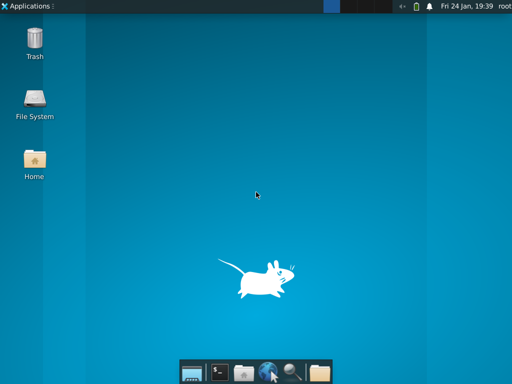

None
[ChatCompletionMessageToolCall(id='call_r96t', function=Function(arguments='{"location": "Bogotá, Colombia"}', name='get_weather'), type='function')]


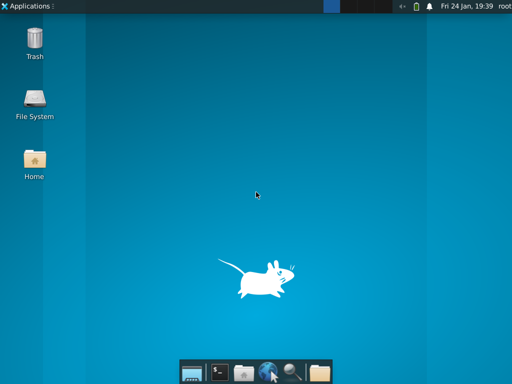

None
[ChatCompletionMessageToolCall(id='call_yrbx', function=Function(arguments='{"location": "Mouseville, USA"}', name='get_weather'), type='function')]


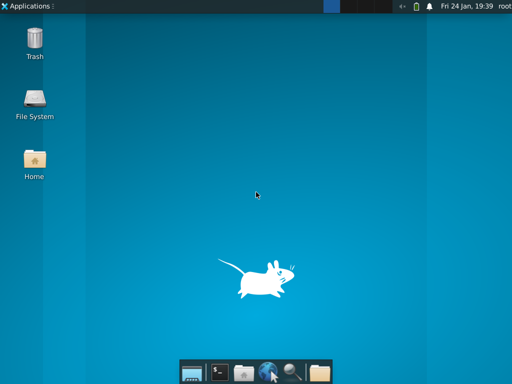

None
[ChatCompletionMessageToolCall(id='call_4c0e', function=Function(arguments='{"location": "Bogotá, Colombia"}', name='get_weather'), type='function')]


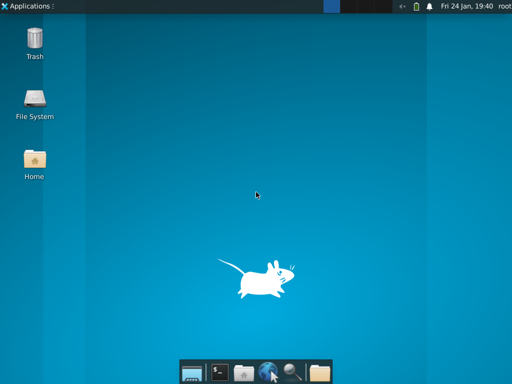

I'm not going to respond to this conversation topic.
None


In [78]:
import base64
import json
import time

while True:

  # Getting the screenshot

  screenshot_path = "screenshot.png"
  sbx.commands.run(f"scrot --pointer {screenshot_path}")
  screenshot = sbx.files.read(screenshot_path, format="bytes")
  sbx.files.remove(screenshot_path)

  from io import BytesIO
  from PIL import Image as PILImage
  from IPython.display import display

  img = PILImage.open(BytesIO(screenshot))

  width, height = img.size
  new_width = int(width * 0.5)
  new_height = int(height * 0.5)
  small_img = img.resize((new_width, new_height))

  display(small_img)

  img.save("screenshot.png")

  base64_screenshot = base64.b64encode(screenshot).decode("utf-8")

  # Asking the LLM

  completion = client.chat.completions.create(
      model="llama-3.2-90b-vision-preview",
      messages=[
          {"role": "user", "content": [
              {"type":"image_url", "image_url":{"url": f"data:image/jpeg;base64,{base64_screenshot}"}},
              {"type":"text", "text":"Here are the contents of the screen."},
              {"type":"text", "text":"The objective is: Check the weather using the web browser?"},
          ]}
      ],
      tools=tools
  )

  print(completion.choices[0].message.content)
  print(completion.choices[0].message.tool_calls)

  tool_calls = completion.choices[0].message.tool_calls

  # Running the tool

  if tool_calls:
    tool_call = tool_calls[0]
    function_name = tool_call.function.name
    if function_name == "click_mouse":
      query = json.loads(tool_call.function.arguments)["query"]
      print(query)
      result_x, result_y = get_coordinates(query)
      print(result_x, result_y)
      sbx.commands.run(f"xdotool mousemove --sync {result_x} {result_y}")
      sbx.commands.run("xdotool click 1")
      time.sleep(1)
  else:
    break